In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

%matplotlib inline

### 1. Dataset

In [2]:
dataset = pd.read_csv("classification.csv")
dataset

,x1,x2,label
0,0.448196,0.130705,0.0
1,0.773273,0.086142,0.0
2,0.418814,0.634072,1.0
3,0.951985,0.403000,0.0
4,0.628209,0.040618,0.0
...,...,...,...
195,0.213643,0.266799,1.0
196,0.853088,0.248827,0.0
197,0.818051,0.490837,0.0
198,0.761045,0.977934,1.0


In [3]:
X = dataset[['x1', 'x2']].values
y = dataset[['label']].values

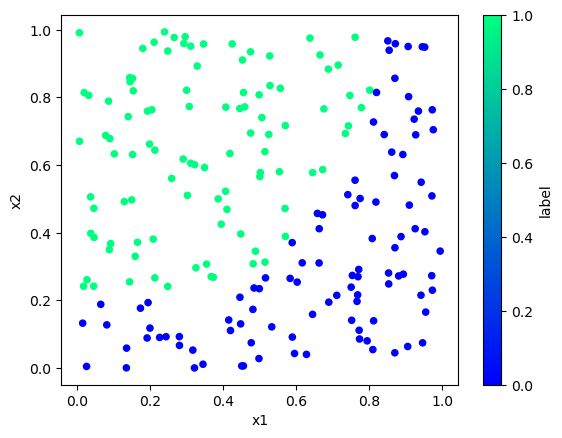

In [4]:
dataset.plot.scatter(x='x1',y='x2', c='label', colormap='winter')
plt.show()

### 2. Modèle


In [5]:
# La fonction sigmoide
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [6]:
def initialisation(X):
    W = np.random.randn(X.shape[1], 1)
    b = np.random.randn(1)
    return (W, b)

In [7]:
# Modèle
def modele(X, W, b):
    Z = X.dot(W) + b
    A = sigmoid(Z)
    return A

W,b=initialisation(X)
modele(X, W, b)

### 3. Fonction Coût 

In [8]:
def log_loss(y, A):
    return 1/len(y) * np.sum(-y * np.log(A) - (1 - y) * np.log(1 - A))

### 4. Optimisation - Gradient et Descente de Gradient

In [9]:
def gradients(X, A, y):
    dW = 1/len(y) * np.dot(X.T, A - y)
    db = 1/len(y) * np.sum(A - y)
    return (dW, db)

In [10]:
def optimisation(X, W, b, A, y, learning_rate):
    dW, db = gradients(X, A, y)
    W = W - learning_rate * dW
    b = b - learning_rate * db
    return (W, b)

### 5. Prédiction

In [11]:
def predict(X, W, b):
    A = modele(X, W, b)
    print(A)
    return A >= 0.5

### 5. Modèle final

In [12]:
def regression_logistique(X, y, learning_rate=0.1, n_iter=10000):
  # Initialisation
    W, b = initialisation(X)
    loss_history = []
  # Entrainement
    for i in range(n_iter):
        A = modele(X, W, b)
        loss_history.append(log_loss(y, A))
        W, b = optimisation(X, W, b, A, y, learning_rate=0.1)

  # Prediction
    plt.plot(loss_history)
    plt.xlabel('n_iteration')
    plt.ylabel('Log_loss')
    plt.title('Evolution des erreurs')
    return W,b

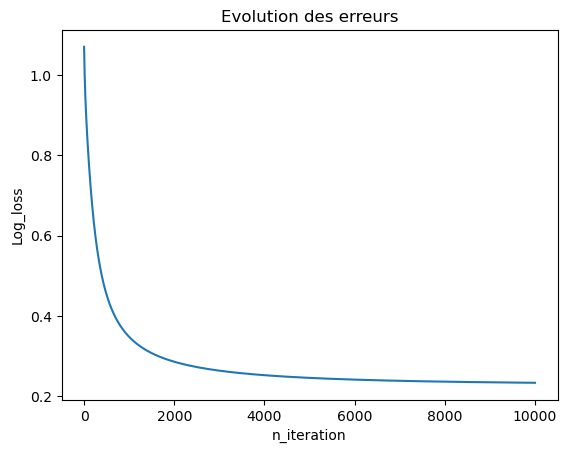

In [13]:
W,b=regression_logistique(X, y)

### 5. 1 Evaluation du modèle et Visualisation


In [14]:
from sklearn.metrics import accuracy_score
y_pred = predict(X, W, b)
print("Accuracy=",accuracy_score(y, y_pred))

[[6.88201815e-02]
 [2.19838952e-03]
 [9.07126176e-01]
 [7.19388266e-03]
 [5.77511570e-03]
 [5.77326536e-01]
 [7.57140226e-03]
 [2.12953777e-01]
 [6.71480653e-01]
 [3.47187113e-01]
 [9.05501088e-01]
 [1.56475663e-02]
 [1.12261555e-01]
 [9.50831040e-01]
 [9.25222048e-01]
 [6.07594999e-01]
 [9.88793457e-01]
 [1.71490849e-03]
 [9.28462971e-01]
 [9.98557199e-01]
 [9.18206276e-01]
 [7.25543602e-01]
 [9.99468905e-01]
 [3.08427595e-01]
 [8.63127717e-01]
 [1.34006918e-01]
 [9.91397305e-01]
 [8.28971785e-01]
 [9.66209959e-01]
 [9.55590835e-01]
 [6.82488919e-02]
 [9.58038978e-01]
 [7.13432182e-01]
 [4.30202760e-01]
 [3.67706808e-01]
 [9.90172048e-01]
 [9.64748469e-01]
 [4.13652901e-01]
 [9.08207491e-01]
 [1.53229132e-01]
 [1.16753259e-03]
 [9.57040106e-01]
 [1.47459643e-01]
 [3.25800086e-02]
 [9.47936242e-01]
 [4.83003401e-01]
 [2.63653460e-01]
 [4.75380427e-01]
 [9.94982064e-01]
 [1.31264643e-02]
 [8.79645493e-01]
 [9.98947065e-01]
 [9.76754284e-01]
 [2.68657397e-01]
 [1.01922382e-02]
 [7.038698

[0.60836289]
[ True]
[0.00193366]
[False]
[0.3099988]
[False]


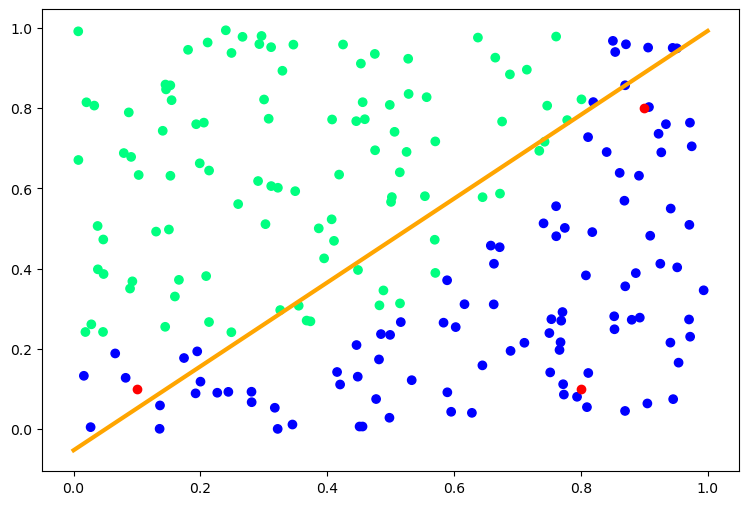

In [ ]:
# Visualiser le dataset
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(X[:,0], X[:, 1], c=y, cmap='winter')

# Dessiner la frontière de décision
x1 = np.linspace(0, 1, 200)
x2 = ( - W[0] * x1 - b) / W[1]
ax.plot(x1, x2, c='orange', lw=3)

# Prédire la classe de nouveaux éléments
new_1=np.array([0.1,0.1])
new_2=np.array([0.8,0.1])
new_3=np.array([0.9,0.8])
ax.scatter(new_1[0], new_1[1], c='r')
ax.scatter(new_2[0], new_2[1], c='r')
ax.scatter(new_3[0], new_3[1], c='r')
print(predict(new_1, W, b))
print(predict(new_2, W, b))
print(predict(new_3, W, b))

plt.show()

In [16]:
#Affichage de la matrice de confusion

from sklearn.metrics import confusion_matrix
y_pred = predict(X, W, b)
cm = confusion_matrix(y, y_pred)
print(cm)

[[6.88201815e-02]
 [2.19838952e-03]
 [9.07126176e-01]
 [7.19388266e-03]
 [5.77511570e-03]
 [5.77326536e-01]
 [7.57140226e-03]
 [2.12953777e-01]
 [6.71480653e-01]
 [3.47187113e-01]
 [9.05501088e-01]
 [1.56475663e-02]
 [1.12261555e-01]
 [9.50831040e-01]
 [9.25222048e-01]
 [6.07594999e-01]
 [9.88793457e-01]
 [1.71490849e-03]
 [9.28462971e-01]
 [9.98557199e-01]
 [9.18206276e-01]
 [7.25543602e-01]
 [9.99468905e-01]
 [3.08427595e-01]
 [8.63127717e-01]
 [1.34006918e-01]
 [9.91397305e-01]
 [8.28971785e-01]
 [9.66209959e-01]
 [9.55590835e-01]
 [6.82488919e-02]
 [9.58038978e-01]
 [7.13432182e-01]
 [4.30202760e-01]
 [3.67706808e-01]
 [9.90172048e-01]
 [9.64748469e-01]
 [4.13652901e-01]
 [9.08207491e-01]
 [1.53229132e-01]
 [1.16753259e-03]
 [9.57040106e-01]
 [1.47459643e-01]
 [3.25800086e-02]
 [9.47936242e-01]
 [4.83003401e-01]
 [2.63653460e-01]
 [4.75380427e-01]
 [9.94982064e-01]
 [1.31264643e-02]
 [8.79645493e-01]
 [9.98947065e-01]
 [9.76754284e-01]
 [2.68657397e-01]
 [1.01922382e-02]
 [7.038698

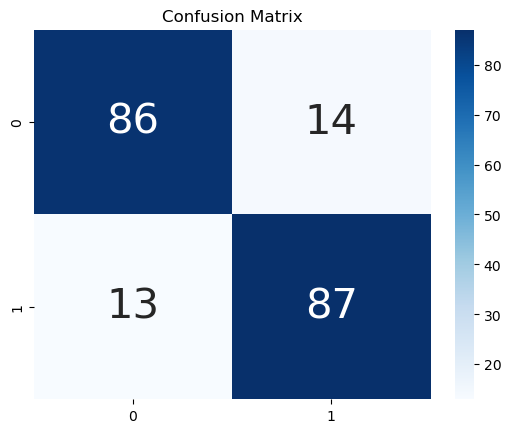

In [17]:
# Plot confusion matrix
import seaborn as sns
import pandas as pd
# confusion matrix sns heatmap 
## https://www.kaggle.com/agungor2/various-confusion-matrix-plots
ax = plt.axes()
df_cm = cm
sns.heatmap(df_cm, annot=True, annot_kws={"size": 30}, fmt='d',cmap="Blues", ax = ax )
ax.set_title('Confusion Matrix')
plt.show()